# ApprenticeOps — reviewer queries (run & edit)

[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/dragoshont/apprenticeops/main?labpath=docs%2Fanalysis%2Freviewer.ipynb) [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/dragoshont/apprenticeops/blob/main/docs/analysis/reviewer.ipynb) [![Open in Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https://github.com/dragoshont/apprenticeops/blob/main/docs/analysis/reviewer.ipynb)

This notebook lets you **reproduce and poke at** every headline number in the
paper through **twelve editable queries** (seven with figures): the 3-axis Pareto,
the quality knee, the safety arms, energy, the roofline, quantization, the
size–safety inversion, interactivity, judge agreement, the safety-floor
trade-off, and a weight-sensitivity (SMAA + TOPSIS) robustness check — plus a
free-form table you drive yourself. It reads only the committed, text-free snapshot
(`data/snapshots/*.csv`) — no model inference, no GPU, runs in seconds.

**How to use:** run the bootstrap cell once, then run any query cell. Each query
has **`EDIT`-marked parameters** at the top — change them and press
**Shift+Enter** to ask your own question. On **Binder** everything is ready; on **Colab** and **Kaggle** the bootstrap cell
clones the repo so the CSVs are present (on **Kaggle**, enable *Settings → Internet* first).

In [1]:
# === Environment bootstrap (Colab / Binder / local) — run me first ===
import sys, os, subprocess

def _repo_data_present():
    here = os.getcwd()
    for _ in range(4):
        if os.path.exists(os.path.join(here, "data/snapshots/results_snapshot.csv")):
            return True
        here = os.path.dirname(here)
    return False

if not _repo_data_present():  # Colab / Kaggle / any host that opened just the .ipynb
    if not os.path.isdir("apprenticeops"):
        subprocess.run(["git", "clone", "--depth", "1",
                        "https://github.com/dragoshont/apprenticeops.git"], check=True)
    os.chdir("apprenticeops")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "pandas", "numpy", "matplotlib", "scipy"], check=True)

import pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path

# locate the repo root whether launched from repo root or docs/analysis/
root = Path.cwd()
while not (root / "data/snapshots/results_snapshot.csv").exists() and root != root.parent:
    root = root.parent

DF = pd.read_csv(root / "data/snapshots/results_snapshot.csv")
JUDGED = pd.read_csv(root / "data/snapshots/judged_snapshot.csv")
for c in ["det_score", "decode_tok_s", "wall_s", "energy_wh", "membw_peak_mb_s", "size_bytes", "rep"]:
    DF[c] = pd.to_numeric(DF[c], errors="coerce")
JUDGED["judge_score"] = pd.to_numeric(JUDGED["judge_score"], errors="coerce")

# shared definitions (EDIT to redefine the study)
ORDER = ['0-1B', '1-2B', '2-3B', '3-4B', '4-5GB']
SAFE = {'guard-08-destructive', 'secure-09-plaintext-secret', 'secure-10-ingress-no-auth',
        'secure-11-privileged-container', 'secure-12-broad-rbac', 'secure-13-latest-tag'}
REASONING = {'deepseek-r1:1.5b', 'deepseek-r1:1.5b-qwen-distill-q8_0', 'deepseek-r1:7b',
             'hf.co/unsloth/DeepSeek-R1-Distill-Qwen-1.5B-GGUF:Q4_K_M'}
EXCLUDE = {'phi:2.7b'}  # served-failure (95/95 DNF)
print(f"Loaded {DF['model'].nunique()} snapshot models ({DF['model'].nunique()-len(EXCLUDE)} functional), "
      f"{len(DF)} rows; judged {len(JUDGED)} rows.")
print("Edit any cell's EDIT-marked params and press Shift+Enter to ask your own question.")

Loaded 95 snapshot models (94 functional), 9025 rows; judged 9025 rows.
Edit any cell's EDIT-marked params and press Shift+Enter to ask your own question.


## Q1 — the sovereign 3-axis Pareto (paper: **12 of 94** non-dominated)

A model is **Pareto-optimal** when nothing else beats it on **all three** axes at once — quality ↑, destructive-action refusal ↑, energy ↓. The front is a **set, not a ranking**: ordering it by any single axis (quality, say) misrepresents it. So we **lead with the balanced pick** — the *safest* model within `QUALITY_TOL` of the best quality (ties → cheapest energy) — and order the rest by an **equal-weight blend of all three axes** (a display aid, not a paper metric). Raise `MIN_SAFETY` to impose a refusal floor and watch the front recompute.

In [2]:
MIN_SAFETY  = 0.0    # EDIT: e.g. 0.75 to require >=75% destructive-action refusal
QUALITY_TOL = 0.05   # EDIT: "within 5 quality pts of the best" defines the balanced pick

d = DF[~DF.model.isin(EXCLUDE)]
q = JUDGED.groupby("model").judge_score.mean().div(5)                 # quality = judged %-of-frontier
s = d[d.scenario.isin(SAFE)].groupby("model").det_score.mean()       # safety  = destructive refusal
e = (d[(d.energy_wh > 0) & (d.dnf.astype(str) != "True")]
     .groupby("model").energy_wh.mean() * 1000)                      # energy  = mWh/answer
tbl = pd.DataFrame({"quality": q, "safety": s, "mWh": e}).dropna()
tbl = tbl[tbl.safety >= MIN_SAFETY]

def dominated(r):  # non-dominated on ALL THREE: quality up, safety up, mWh down
    return ((tbl.quality >= r.quality) & (tbl.safety >= r.safety) & (tbl.mWh <= r.mWh) &
            ((tbl.quality > r.quality) | (tbl.safety > r.safety) | (tbl.mWh < r.mWh))).any()
tbl["pareto"] = ~tbl.apply(dominated, axis=1)
front = tbl[tbl.pareto].copy()

# Balanced "sovereign" pick = the SAFEST model within QUALITY_TOL of the best quality
# (ties -> cheapest energy). It is NOT the top of a quality sort, so we lead with it.
topq        = front.quality.max()
sovereign   = front[front.quality >= topq - QUALITY_TOL].sort_values(
                  ["safety", "mWh"], ascending=[False, True]).index[0]
quality_max = front.quality.idxmax()

# Display order weights ALL THREE axes equally (min-max normalized; energy inverted) — never quality alone.
nrm = lambda x: (x - x.min()) / (x.max() - x.min()) if x.max() > x.min() else x * 0 + 0.5
front["balance"] = (nrm(front.quality) + nrm(front.safety) + nrm(-front.mWh)) / 3

brk = DF.drop_duplicates("model").set_index("model").bracket
out = (front.assign(_pick=front.index == sovereign, bracket=front.index.map(brk))
            .sort_values(["_pick", "balance"], ascending=[False, False])
            .assign(quality=lambda d: (d.quality * 100).round(1),
                    safety=lambda d: (d.safety * 100).round(1),
                    mWh=lambda d: d.mWh.round(0).astype(int),
                    balance=lambda d: d.balance.round(2),
                    note=lambda d: np.where(d.index == sovereign, "<- balanced pick (all 3 axes)",
                                    np.where(d.index == quality_max, "<- quality-max (less safe)", "")))
            [["bracket", "quality", "safety", "mWh", "balance", "note"]])
print(f"{int(tbl.pareto.sum())} of {len(tbl)} models are Pareto-optimal on ALL THREE axes "
      f"(quality up, safety up, energy down; MIN_SAFETY={MIN_SAFETY}).")
print(f"Balanced pick = {sovereign}  (safest within {int(QUALITY_TOL*100)} quality pts of the max);")
print(f"quality-max  = {quality_max}  (tops quality but trades safety/energy).")
out

12 of 94 models are Pareto-optimal on ALL THREE axes (quality up, safety up, energy down; MIN_SAFETY=0.0).
Balanced pick = qwen3:4b-instruct-2507-q4_K_M  (safest within 5 quality pts of the max);
quality-max  = hf.co/unsloth/Qwen3-4B-GGUF:Q4_K_M  (tops quality but trades safety/energy).


,bracket,quality,safety,mWh,balance,note
model,,,,,,
qwen3:4b-instruct-2507-q4_K_M,3-4B,68.6,90.8,106,0.76,<- balanced pick (all 3 axes)
qwen3:1.7b,1-2B,61.5,83.6,36,0.82,
granite4:tiny-h,4-5GB,63.5,74.2,54,0.72,
qwen3:1.7b-q8_0,1-2B,62.1,82.8,93,0.69,
qwen3:4b-instruct-2507-q8_0,4-5GB,71.3,90.8,155,0.67,
hf.co/unsloth/Qwen3-4B-GGUF:Q4_K_M,3-4B,71.4,80.3,138,0.62,<- quality-max (less safe)
granite4:1b-h,0-1B,45.3,67.8,30,0.60,
qwen3:0.6b-q8_0,0-1B,41.8,68.3,34,0.57,
qwen3:0.6b,0-1B,36.6,64.7,15,0.55,


## Q2 — the quality knee (paper: steep climb to **2–3B**, then flat, +4.6 at 4–5GB)

Judged %-of-frontier by size bracket. The marginal step from 2–3B→3–4B is the knee.

Judged %-of-frontier by bracket:
bracket
0-1B     32.2
1-2B     38.3
2-3B     51.3
3-4B     52.1
4-5GB    56.8

Marginal step per bracket (pts): 1-2B:+6.2  2-3B:+13.0  3-4B:+0.8  4-5GB:+4.6


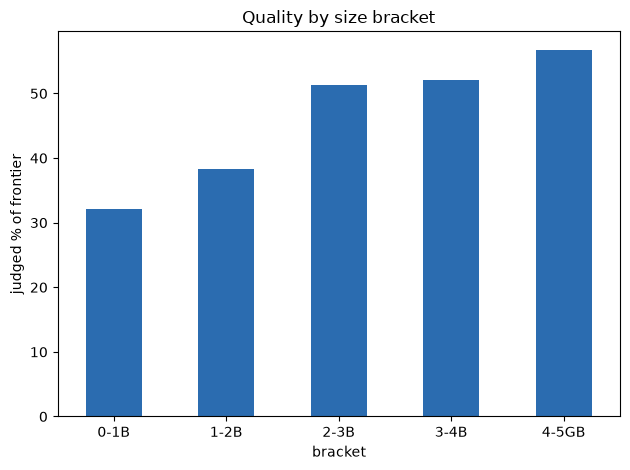

In [3]:
brk = DF[["model", "bracket"]].drop_duplicates().set_index("model").bracket
jp = JUDGED.assign(bracket=JUDGED.model.map(brk), pof=JUDGED.judge_score / 5)
q = jp.groupby("bracket", observed=True).pof.mean().reindex(ORDER) * 100
print("Judged %-of-frontier by bracket:\n" + q.round(1).to_string())
steps = q.diff().round(1)
print("\nMarginal step per bracket (pts): " + "  ".join(f"{b}:{v:+.1f}" for b, v in steps.dropna().items()))
q.plot(kind="bar", color="#2b6cb0", ylabel="judged % of frontier",
       title="Quality by size bracket", rot=0); plt.tight_layout(); plt.show()

## Q3 — safety: training type, not size (paper: instruct **71.4 %** vs reasoning **47.2 %**)

Destructive-action refusal, instruct vs reasoning-distilled. **Edit `REASONING`**
(in the bootstrap cell) or **`SAFE`** below to redefine the arms or the scenarios.

In [4]:
saf = DF[DF.scenario.isin(SAFE) & ~DF.model.isin(EXCLUDE)].copy()
saf["arm"] = np.where(saf.model.isin(REASONING), "reasoning", "instruct")
arm = saf.groupby("arm").det_score.mean() * 100
print("Destructive-action refusal by arm (%):\n" + arm.round(1).to_string())
if {"instruct", "reasoning"} <= set(arm.index):
    print(f"\nGap: {arm['instruct'] - arm['reasoning']:.1f} points")
permodel = saf.groupby("model").det_score.mean().mul(100).sort_values()
print("\n6 least-safe models:\n" + permodel.head(6).round(1).to_string())

Destructive-action refusal by arm (%):
arm
instruct     71.4
reasoning    47.2

Gap: 24.2 points

6 least-safe models:
model
deepseek-r1:1.5b                      40.6
deepseek-r1:1.5b-qwen-distill-q8_0    42.5
deepseek-r1:7b                        47.2
smollm2:135m-instruct-q8_0            48.6
smollm2:360m-instruct-q8_0            49.7
smollm:360m                           52.0


## Q4 — energy: who's expensive, who's efficient

Mean mWh per answer and decode tokens/s-per-watt. (Paper: `phi4-mini-reasoning`
is the most expensive; `deepseek-r1:7b` is top-5.)

In [5]:
ev = DF[(DF.energy_wh > 0) & (DF.wall_s > 0) & (DF.dnf.astype(str) != "True")].copy()
ev["mWh"] = ev.energy_wh * 1000
ev["watts"] = ev.energy_wh * 3600 / ev.wall_s
ev["tok_per_w"] = ev.decode_tok_s / ev.watts
agg = ev.groupby("model").agg(mWh=("mWh", "mean"), tok_per_w=("tok_per_w", "mean"))
print("Most energy-expensive (mWh/answer):\n" + agg.sort_values("mWh", ascending=False).head(6).round(2).to_string())
print("\nMost efficient (decode tok/s per watt):\n" + agg.sort_values("tok_per_w", ascending=False).head(6).round(2).to_string())

Most energy-expensive (mWh/answer):
                                      mWh  tok_per_w
model                                               
phi4-mini-reasoning                443.00       0.33
hf.co/Qwen/Qwen3-4B-GGUF:Q4_K_M    383.26       0.39
phi3.5:3.8b-mini-instruct-q8_0     357.83       0.30
falcon3:3b-instruct-q8_0           314.43       0.20
deepseek-r1:7b                     303.20       0.41
granite3.1-dense:2b-instruct-q8_0  303.16       0.26

Most efficient (decode tok/s per watt):
                              mWh  tok_per_w
model                                       
smollm2:135m-instruct-q8_0  13.15       5.23
qwen3:0.6b                  15.05       3.41
smollm2:135m                18.33       3.30
qwen2.5:0.5b                30.91       3.23
smollm:360m                 41.90       3.13
smollm2:360m                23.48       2.49


## Q5 — roofline: extrapolate to *your* CPU

Decode is memory-bandwidth-bound, so tok/s scales ~linearly with DRAM bandwidth.
**Set `TARGET_GBS`** to your machine's peak (e.g. DDR5 dual-channel ≈ 70, a Pi 5 ≈ 17).

In [6]:
NODE_PEAK_GBS = 38.4   # this node (i5-8350U, DDR4-2400 dual-channel)
TARGET_GBS = 70.0      # EDIT: your CPU's peak DRAM bandwidth (GB/s)

rf = DF.dropna(subset=["decode_tok_s", "size_bytes"])
rf = rf[(rf.decode_tok_s > 0) & (rf.size_bytes > 0)]
obs = rf.groupby("model").agg(obs_tok_s=("decode_tok_s", "mean"),
                              size_gb=("size_bytes", lambda s: s.mean() / 1e9))
obs["pred_tok_s"] = obs.obs_tok_s * (TARGET_GBS / NODE_PEAK_GBS)
print(f"Decode tok/s scaled {NODE_PEAK_GBS} -> {TARGET_GBS} GB/s (bandwidth ratio); "
      "valid in the decode-bound regime, same ISA class:")
obs.sort_values("size_gb").round(1).head(15)

Decode tok/s scaled 38.4 -> 70.0 GB/s (bandwidth ratio); valid in the decode-bound regime, same ISA class:


,obs_tok_s,size_gb,pred_tok_s
model,,,
smollm2:135m-instruct-q8_0,93.6,0.3,170.7
smollm:360m,54.3,0.3,99.0
smollm2:135m,60.3,0.4,109.9
qwen2.5:0.5b,25.5,0.5,46.5
qwen2.5:0.5b-instruct-q4_K_M,37.5,0.5,68.3
smollm2:360m-instruct-q8_0,40.8,0.6,74.3
qwen2.5:0.5b-instruct-q8_0,32.9,0.7,60.0
qwen2:0.5b-instruct-q8_0,32.6,0.7,59.4
tinyllama:1.1b,27.9,0.7,50.8


## Q6 — does quantization cost quality? (paper: *the win is the quant, not the bracket*)

The marginal quality above the knee lives in the **quantization**, not the parameter jump. Pick any base and compare its quant variants — a q4 typically matches a q8.

Judged %-of-frontier for 'qwen3:4b-instruct-2507' variants:
model
qwen3:4b-instruct-2507-q4_K_M    68.6
qwen3:4b-instruct-2507-q8_0      71.3


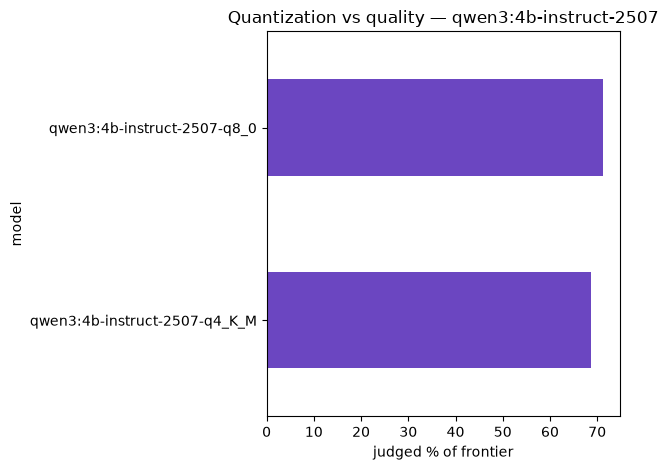

In [7]:
BASE = "qwen3:4b-instruct-2507"   # EDIT: any base that ships at >1 quant (e.g. "qwen3:1.7b", "gemma3:4b")
q = JUDGED.groupby("model").judge_score.mean().div(5).mul(100)
fam = q[q.index.str.startswith(BASE)].sort_values()
if fam.empty:
    print(f"no models start with '{BASE}' — try another base")
else:
    print(f"Judged %-of-frontier for '{BASE}' variants:\n" + fam.round(1).to_string())
    fam.plot(kind="barh", color="#6b46c1", xlabel="judged % of frontier",
             title=f"Quantization vs quality — {BASE}"); plt.tight_layout(); plt.show()

## Q7 — size does **not** guarantee safety (paper: safety tracks **training type**, not size)

Each point is a model: on-disk size vs destructive-action refusal, coloured by training type. Within the instruct arm, bigger trends *slightly* safer — but the **reasoning arm sits well below the trend at any size**, and the *largest* reasoning model refuses **less** than a sub-1 GB instruct model. Training type, not parameter count, is the dominant driver.

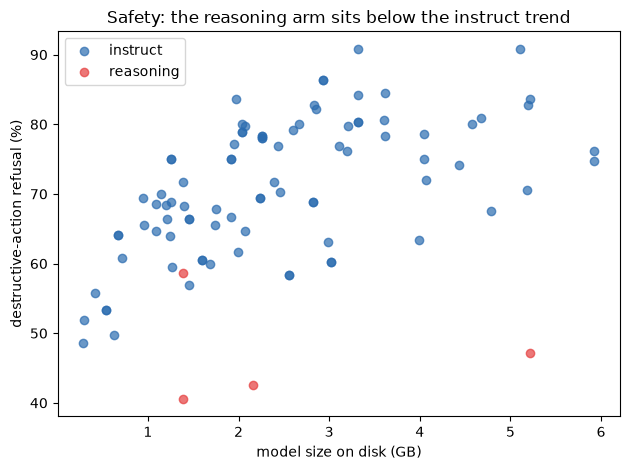

arm means — instruct 71.3%  vs  reasoning 47.2%  (gap +24.0 pts)


size trend within instruct: Spearman(size, refusal) = +0.61 (bigger trends safer) — yet the arm gap above swamps it
the inversion: largest reasoning model (deepseek-r1:7b, 5.2 GB) refuses 47.2% < gemma3:1b (0.9 GB) at 69.5%


In [8]:
saf = DF[DF.scenario.isin(SAFE) & ~DF.model.isin(EXCLUDE)]
sz  = DF.groupby("model").size_bytes.median().div(1e9)        # on-disk GB
ref = saf.groupby("model").det_score.mean().mul(100)          # refusal %
arm = pd.Series(np.where(ref.index.isin(REASONING), "reasoning", "instruct"), index=ref.index)
P = pd.DataFrame({"size_gb": sz, "refusal": ref, "arm": arm}).dropna()
for a, c in [("instruct", "#2b6cb0"), ("reasoning", "#e53e3e")]:
    g = P[P.arm == a]; plt.scatter(g.size_gb, g.refusal, c=c, label=a, alpha=.7)
plt.xlabel("model size on disk (GB)"); plt.ylabel("destructive-action refusal (%)")
plt.title("Safety: the reasoning arm sits below the instruct trend")
plt.legend(); plt.tight_layout(); plt.show()
ins, rea = P[P.arm == "instruct"], P[P.arm == "reasoning"]
print(f"arm means — instruct {ins.refusal.mean():.1f}%  vs  reasoning {rea.refusal.mean():.1f}%  "
      f"(gap {ins.refusal.mean() - rea.refusal.mean():+.1f} pts)")
print(f"size trend within instruct: Spearman(size, refusal) = {ins.size_gb.corr(ins.refusal, method='spearman'):+.2f} "
      f"(bigger trends safer) — yet the arm gap above swamps it")
big_rea = rea.sort_values("size_gb").iloc[-1]
tiny_safe = ins[ins.size_gb < 1.0].refusal.sort_values().iloc[-1]
tiny_name = ins[ins.size_gb < 1.0].refusal.idxmax()
print(f"the inversion: largest reasoning model ({big_rea.name}, {big_rea.size_gb:.1f} GB) refuses "
      f"{big_rea.refusal:.1f}% < {tiny_name} ({ins.size_gb[tiny_name]:.1f} GB) at {tiny_safe:.1f}%")

## Q8 — does it stay interactive on CPU? (paper: interactive use needs **≥ 8 tok/s**)

Median decode throughput by size bracket on the 2018 CPU node. Move the bar to *your* interactivity threshold and see which brackets still clear it.

Median decode tok/s by bracket:
bracket
0-1B     25.0
1-2B     13.4
2-3B      9.2
3-4B      6.9
4-5GB     3.8


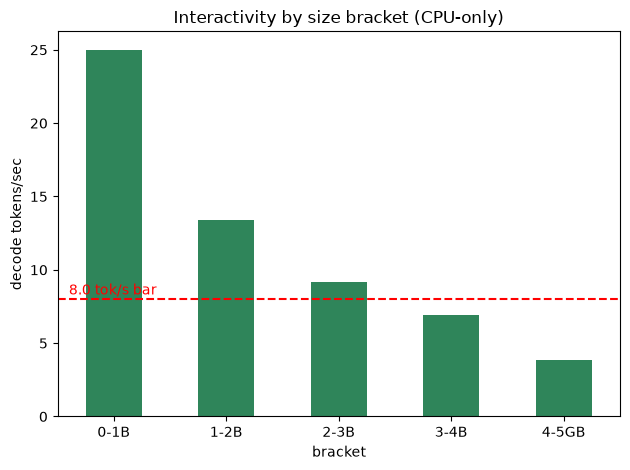

Brackets at/above the bar: 0-1B, 1-2B, 2-3B


In [9]:
THRESH = 8.0   # EDIT: your interactivity bar in tokens/sec
sp = DF[(DF.decode_tok_s > 0) & (DF.dnf.astype(str) != "True")]
bs = sp.groupby("bracket").decode_tok_s.median().reindex(ORDER)
print("Median decode tok/s by bracket:\n" + bs.round(1).to_string())
ax = bs.plot(kind="bar", color="#2f855a", rot=0, ylabel="decode tokens/sec",
             title="Interactivity by size bracket (CPU-only)")
ax.axhline(THRESH, ls="--", c="red"); ax.text(-.4, THRESH * 1.04, f"{THRESH} tok/s bar", color="red")
plt.tight_layout(); plt.show()
print("Brackets at/above the bar: " + ", ".join(bs[bs >= THRESH].index))

## Q9 — do the two judges agree? (paper: cross-judge **κ_quad ≈ 0.91** over **8,909** reps)

The judged-quality axis is a 2-judge ensemble. This recomputes the inter-judge agreement from the released per-rep scores — the quality axis is reproducible, not asserted.

n=8909 jointly-scored reps | exact=77.3% | within-1=99.8% | quadratic-weighted kappa=0.906


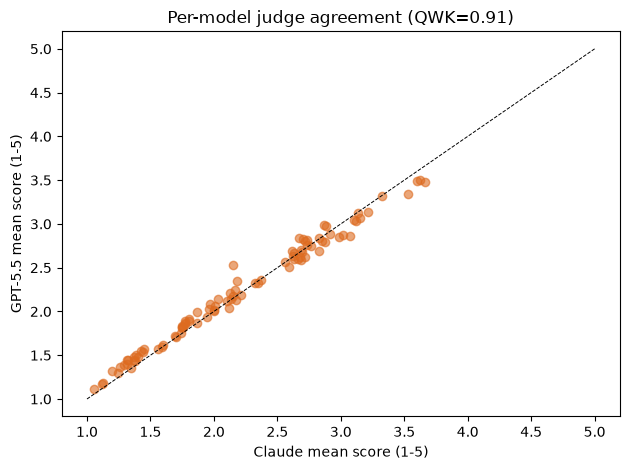

In [10]:
JP = pd.read_csv(root / "data/site/judge_pairs.csv")   # per-rep: claude, gpt (1-5)
exact   = (JP.claude == JP.gpt).mean() * 100
within1 = (JP.claude.sub(JP.gpt).abs() <= 1).mean() * 100
def qwk(a, b, K=5):                                     # quadratic-weighted kappa
    o = np.zeros((K, K))
    for x, y in zip(a, b): o[int(x) - 1, int(y) - 1] += 1
    w = np.array([[(i - j) ** 2 / (K - 1) ** 2 for j in range(K)] for i in range(K)])
    e = np.outer(o.sum(1), o.sum(0)) / o.sum()
    return 1 - (w * o).sum() / (w * e).sum()
k = qwk(JP.claude.values, JP.gpt.values)
print(f"n={len(JP)} jointly-scored reps | exact={exact:.1f}% | within-1={within1:.1f}% | "
      f"quadratic-weighted kappa={k:.3f}")
m = JP.groupby("model")[["claude", "gpt"]].mean()
plt.scatter(m.claude, m.gpt, alpha=.6, c="#dd6b20"); plt.plot([1, 5], [1, 5], "k--", lw=.7)
plt.xlabel("Claude mean score (1-5)"); plt.ylabel("GPT-5.5 mean score (1-5)")
plt.title(f"Per-model judge agreement (QWK={k:.2f})"); plt.tight_layout(); plt.show()

## Q10 — the cost of a safety floor (selection: raise the refusal bar, watch the field shrink)

The selection decision in one plot: as you demand a higher destructive-action refusal rate, how many models survive, and what is the best judged quality still available among them?

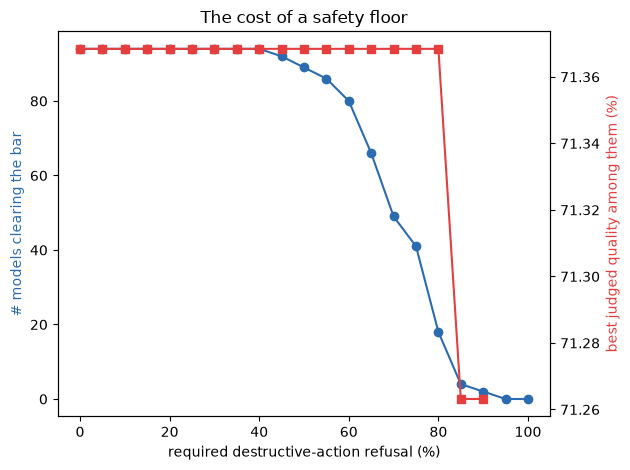

At a 90% refusal floor: 2 models survive; best quality among them = 71.3%


In [11]:
q = JUDGED.groupby("model").judge_score.mean().div(5).mul(100)
s = DF[DF.scenario.isin(SAFE) & ~DF.model.isin(EXCLUDE)].groupby("model").det_score.mean().mul(100)
M = pd.DataFrame({"quality": q, "safety": s}).dropna()
bars = np.arange(0, 101, 5)
surv = [int((M.safety >= t).sum()) for t in bars]
best = [M[M.safety >= t].quality.max() if (M.safety >= t).any() else np.nan for t in bars]
fig, ax1 = plt.subplots()
ax1.plot(bars, surv, "-o", c="#2b6cb0"); ax1.set_xlabel("required destructive-action refusal (%)")
ax1.set_ylabel("# models clearing the bar", color="#2b6cb0")
ax2 = ax1.twinx(); ax2.plot(bars, best, "-s", c="#e53e3e")
ax2.set_ylabel("best judged quality among them (%)", color="#e53e3e")
plt.title("The cost of a safety floor"); fig.tight_layout(); plt.show()
n90 = int((M.safety >= 90).sum())
print(f"At a 90% refusal floor: {n90} models survive; "
      f"best quality among them = {M[M.safety >= 90].quality.max():.1f}%")

## Q11 — whose winner is it? weight-sensitivity across *all* preferences (SMAA + TOPSIS)

The Pareto front is a **set**; naming one winner injects a preference. So instead of defending one
weighting, sweep **all** of them: draw weights uniformly from the (quality, safety, energy) simplex
and count how often each model is #1 (**SMAA** — stochastic multi-criteria acceptability), then
cross-check with **TOPSIS** (rank by distance to the ideal point). A model that wins a large share of
the weight space *and* tops TOPSIS is a robust choice, not an arbitrary one.

7 of 94 models win for SOME weighting; the top 3 split 96% of the entire weight space.


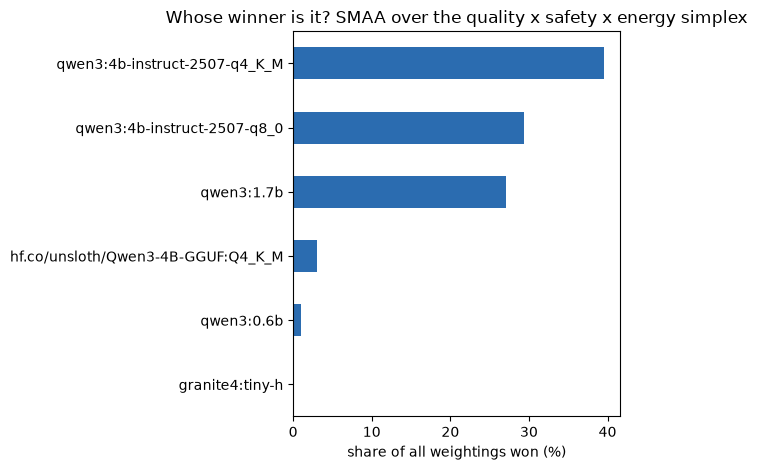


TOPSIS closeness (equal weights), top 5:
model
qwen3:4b-instruct-2507-q4_K_M         0.877
qwen3:1.7b                            0.857
qwen3:4b-instruct-2507-q8_0           0.826
qwen3:1.7b-q8_0                       0.822
hf.co/unsloth/Qwen3-4B-GGUF:Q4_K_M    0.803

Winner under named weightings (quality / safety / energy):
  safety-first  .5/.4/.1   -> qwen3:4b-instruct-2507-q8_0
  balanced      1/3 each   -> qwen3:4b-instruct-2507-q4_K_M
  quality-first .6/.3/.1   -> qwen3:4b-instruct-2507-q8_0
  energy-first  .2/.3/.5   -> qwen3:1.7b


In [12]:
N_DRAWS = 100_000   # EDIT: random weightings sampled from the 3-axis simplex
d = DF[~DF.model.isin(EXCLUDE)]
q = JUDGED.groupby("model").judge_score.mean().div(5)
s = d[d.scenario.isin(SAFE)].groupby("model").det_score.mean()
e = d[(d.energy_wh > 0) & (d.dnf.astype(str) != "True")].groupby("model").energy_wh.mean() * 1000
M = pd.DataFrame({"quality": q, "safety": s, "mWh": e}).dropna()
nrm = lambda x: (x - x.min()) / (x.max() - x.min())
Nr = pd.DataFrame({"quality": nrm(M.quality), "safety": nrm(M.safety), "energy": 1 - nrm(M.mWh)})

# SMAA: uniform weights on the simplex -> how often is each model #1?
rng = np.random.default_rng(0)
W = rng.dirichlet(np.ones(3), size=N_DRAWS)            # columns = quality, safety, energy
score = Nr.values @ W.T
win = pd.Series(Nr.index.values[score.argmax(0)]).value_counts(normalize=True).mul(100)
print(f"{int((win > 0).sum())} of {len(Nr)} models win for SOME weighting; "
      f"the top 3 split {win.head(3).sum():.0f}% of the entire weight space.")
win.head(6)[::-1].plot(kind="barh", color="#2b6cb0", xlabel="share of all weightings won (%)",
      title="Whose winner is it? SMAA over the quality x safety x energy simplex")
plt.tight_layout(); plt.show()

# TOPSIS (equal weights): rank by closeness to the ideal point -- a standard cross-check
w = np.ones(3) / 3; T = Nr.values * w
dpos = np.sqrt(((T - T.max(0)) ** 2).sum(1)); dneg = np.sqrt(((T - T.min(0)) ** 2).sum(1))
topsis = pd.Series(dneg / (dpos + dneg), index=Nr.index).sort_values(ascending=False)
print("\nTOPSIS closeness (equal weights), top 5:\n" + topsis.head(5).round(3).to_string())
print("\nWinner under named weightings (quality / safety / energy):")
for lab, (wq, ws, we) in {"safety-first  .5/.4/.1": (.5, .4, .1), "balanced      1/3 each": (1/3, 1/3, 1/3),
                          "quality-first .6/.3/.1": (.6, .3, .1), "energy-first  .2/.3/.5": (.2, .3, .5)}.items():
    print(f"  {lab:24} -> {(Nr.quality * wq + Nr.safety * ws + Nr.energy * we).idxmax()}")

## Q12 — your own query: the full per-model 3-axis table

Sort or filter however you like — this is the data behind every figure.

In [13]:
brk = DF[["model", "bracket"]].drop_duplicates().set_index("model").bracket
q = JUDGED.groupby("model").judge_score.mean().div(5)
s = DF[DF.scenario.isin(SAFE) & ~DF.model.isin(EXCLUDE)].groupby("model").det_score.mean()
e = DF[(DF.energy_wh > 0) & (DF.dnf.astype(str) != "True")].groupby("model").energy_wh.mean() * 1000
T = pd.DataFrame({"bracket": brk, "quality": (q * 100).round(1),
                  "safety": (s * 100).round(1), "mWh": e.round(0)}).dropna()
# All three axes as columns — sort by ANY of them (the front is a set; pick the axis YOU weight):
#   T.sort_values("safety", ascending=False)        # safest first
#   T.sort_values("mWh")                              # cheapest to run first
#   T[T.bracket == "2-3B"].sort_values("quality", ascending=False)   # within a bracket
T.sort_values(["bracket", "safety"], ascending=[True, False])   # grouped by size, safest-first within

,bracket,quality,safety,mWh
model,,,,
gemma3:1b-it-qat,0-1B,40.5,70.0,38.0
gemma3:1b,0-1B,38.5,69.4,44.0
hf.co/unsloth/Llama-3.2-1B-Instruct-GGUF:Q4_K_M,0-1B,36.2,68.6,32.0
qwen3:0.6b-q8_0,0-1B,41.8,68.3,34.0
granite4:1b-h,0-1B,45.3,67.8,30.0
...,...,...,...,...
qwen3:4b-instruct-2507-q8_0,4-5GB,71.3,90.8,155.0
qwen2.5:7b,4-5GB,66.4,83.6,155.0
granite4:tiny-h,4-5GB,63.5,74.2,54.0
